In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import palettable as pal
import time
import os
import sys
import json

sns.set_context("talk",rc={"font.size":15,"axes.titlesize":15,"axes.labelsize":15})
sns.set_style("whitegrid",{"grid.color": '.9', 'grid.linestyle': '--','axes.edgecolor': '.6', 'xtick.bottom': True,'ytick.left': True})

colorTable = {}
colorTable['k'] = [0,0,0]
colorTable['g'] = [27/255,158/255,119/255]
colorTable['o'] = [217/255,95/255,2/255]
colorTable["p"] = [117/255,112/255,179/255]

from itertools import product

from Bio import SeqIO
from sklearn.decomposition import PCA
import pandas as pd

import overlappingGenes as og

# Standard genetic code
GENETIC_CODE = {
    'TTT': 'F', 'TTC': 'F', 'TTA': 'L', 'TTG': 'L',
    'TCT': 'S', 'TCC': 'S', 'TCA': 'S', 'TCG': 'S',
    'TAT': 'Y', 'TAC': 'Y', 'TAA': '*', 'TAG': '*',
    'TGT': 'C', 'TGC': 'C', 'TGA': '*', 'TGG': 'W',
    'CTT': 'L', 'CTC': 'L', 'CTA': 'L', 'CTG': 'L',
    'CCT': 'P', 'CCC': 'P', 'CCA': 'P', 'CCG': 'P',
    'CAT': 'H', 'CAC': 'H', 'CAA': 'Q', 'CAG': 'Q',
    'CGT': 'R', 'CGC': 'R', 'CGA': 'R', 'CGG': 'R',
    'ATT': 'I', 'ATC': 'I', 'ATA': 'I', 'ATG': 'M',
    'ACT': 'T', 'ACC': 'T', 'ACA': 'T', 'ACG': 'T',
    'AAT': 'N', 'AAC': 'N', 'AAA': 'K', 'AAG': 'K',
    'AGT': 'S', 'AGC': 'S', 'AGA': 'R', 'AGG': 'R',
    'GTT': 'V', 'GTC': 'V', 'GTA': 'V', 'GTG': 'V',
    'GCT': 'A', 'GCC': 'A', 'GCA': 'A', 'GCG': 'A',
    'GAT': 'D', 'GAC': 'D', 'GAA': 'E', 'GAG': 'E',
    'GGT': 'G', 'GGC': 'G', 'GGA': 'G', 'GGG': 'G'
}

def revcomp(seq):
    """Return the reverse complement of a nucleotide sequence string."""
    comp = {'A': 'T', 'T': 'A', 'G': 'C', 'C': 'G'}
    return ''.join(comp[b] for b in reversed(seq))

def get_codons_for_aa(aa):
    """Get all codons that encode a given amino acid."""
    return [codon for codon, amino_acid in GENETIC_CODE.items() if amino_acid == aa]

def get_params_and_stats(pf_name):
    if pf_name in PARAMS_CACHE:
        return PARAMS_CACHE[pf_name], NATURAL_STATS_CACHE[pf_name]
    param_file = os.path.join(BASE_DIR, pf_name, f"{pf_name}_params.dat")
    J, h = og.extract_params(param_file)
    PARAMS_CACHE[pf_name] = [J, h]
    nat_file = os.path.join(BASE_DIR, pf_name, f"{pf_name}_naturalenergies.txt")
    energies = og.load_natural_energies(nat_file)
    NATURAL_STATS_CACHE[pf_name] = (np.mean(energies), np.std(energies))
    return [J, h], (np.mean(energies), np.std(energies))


# Add current directory to path to import overlappingGenes
sys.path.append(os.getcwd())

BASE_DIR = "../../0 bmDCA"
OPTIMAL_TEMPS_FILE = "optimal_temperatures.json"

ITERATIONS = 999_999
N_TRIALS = 30

# --- Load protein families ---
ALL_PF_DIRS = sorted([d for d in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, d)) and d.startswith("PF")])
print(f"Found {len(ALL_PF_DIRS)} Protein Families: {ALL_PF_DIRS}")

# --- Load optimal temperatures ---
if os.path.exists(OPTIMAL_TEMPS_FILE):
    with open(OPTIMAL_TEMPS_FILE, 'r') as f:
        OPTIMAL_TEMPS = json.load(f)
else:
    OPTIMAL_TEMPS = {}

# Precompute params and stats for all PFs (to avoid repeated file IO in workers)
PARAMS_CACHE = {}
NATURAL_STATS_CACHE = {}
for pf in ALL_PF_DIRS:
    params, stats = get_params_and_stats(pf)
    PARAMS_CACHE[pf] = params
    NATURAL_STATS_CACHE[pf] = stats



Found 3 Protein Families: ['PF00004', 'PF00041', 'PF00072']


In [4]:
aa_list = list("ACDEFGHIKLMNPQRSTVWY-")
aa_to_int = {aa: i for i, aa in enumerate(aa_list)}

pf1 = "PF00041"  # Fibronectin type II domain
pf2 = "PF00072"  # Response regulator

params1, (nat_mean1, nat_std1) = PARAMS_CACHE[pf1], NATURAL_STATS_CACHE[pf1]
params2, (nat_mean2, nat_std2) = PARAMS_CACHE[pf2], NATURAL_STATS_CACHE[pf2]
t1 = float(OPTIMAL_TEMPS.get(pf1, 1.0))
t2 = float(OPTIMAL_TEMPS.get(pf2, 1.0))
len1 = len(params1[1]) // 21
len2 = len(params2[1]) // 21

numiterations = 500000

# Length of sequence 1
hvec = params1[1]
len1 = len(hvec) / 21
print(f"Length of sequence 1: {len1} amino acids or 3 x {len1*3} nucleotides")

# Length of sequence 2
hvec = params2[1]
len2 = len(hvec) / 21
print(f"Length of sequence 2: {len2} amino acids or 3 x {len2*3} nucleotides")

# Lengths in nucleotides
l1_nt = int(3*len1) # exclude stop
l2_nt = int(3*len2) # exclude stop

Length of sequence 1: 74.0 amino acids or 3 x 222.0 nucleotides
Length of sequence 2: 108.0 amino acids or 3 x 324.0 nucleotides


In [8]:
ntrial = 300
overlap = 218
final_energies_list_1 = []
final_energies_list_2 = []
best_energies_list_1 = []
best_energies_list_2 = []
energies_1 = []
energies_2 = []
for tr in range(ntrial):
    init_seq = og.initial_seq_no_stops(len1, len2, overlap, quiet=True)
    result = og.overlapped_sequence_generator_int(
        params1, params2, init_seq,
        numberofiterations=numiterations,
        whentosave=.00001,
        quiet=True,
        T1=0.7, T2=0.88,
        nat_mean1=nat_mean1, nat_mean2=nat_mean2,
        std_mean1=nat_std1, std_mean2=nat_std2
    )

    # final_seq = result[0]
    # print(final_seq)

    accepted = result[1]
    energy_history_seq1 = result[2]
    energy_history_seq2 = result[3]
    final_energies = result[4]
    best_energies = result[5]
    best_seq = result[6]
    best_save_idx = result[7]

    # Split best_seq into individual sequences
    seq1_best = best_seq[:l1_nt]
    seq2_best = best_seq[-l2_nt:]

    # Split into triplets and translate
    triplets1 = [seq1_best[i:i+3] for i in range(0, len(seq1_best), 3)]
    triplets2 = [seq2_best[i:i+3] for i in range(0, len(seq2_best), 3)]

    seq1_aa = ''.join([GENETIC_CODE[triplet] for triplet in triplets1])
    seq2_aa = ''.join([GENETIC_CODE[triplet] for triplet in triplets2])

    final_energies_list_1.append(final_energies[0])
    final_energies_list_2.append(final_energies[1])
    best_energies_list_1.append(best_energies[0])
    best_energies_list_2.append(best_energies[1])

    energies_1.append(energy_history_seq1)
    energies_2.append(energy_history_seq2)

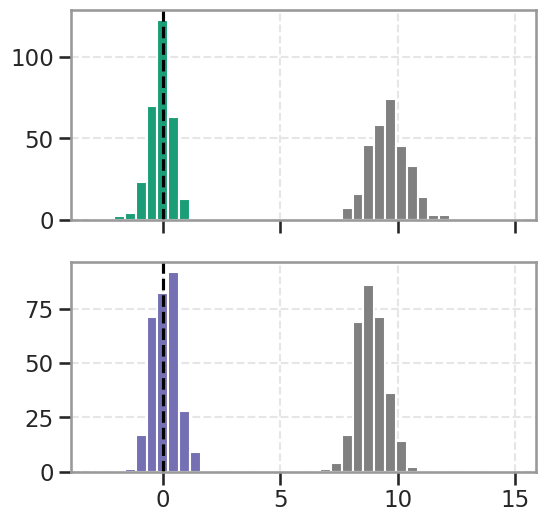

In [9]:
# Plot histogram of initial energies, normalized by natural mean and std

zbins = np.linspace(-3,15, 40)

f1 = np.array([traj[0] for traj in energies_1])
f2 = np.array([traj[0] for traj in energies_2])

# convert to z-scores using natural mean and std
f1_z_init = (f1 - nat_mean1) / nat_std1
f2_z_init = (f2 - nat_mean2) / nat_std2

# Plot histogram of final energies, normalized by natural mean and std
fig, axs = plt.subplots(2,1,figsize=(6,6), sharex = True)

f1 = np.array([traj[-1] for traj in energies_1])
f2 = np.array([traj[-1] for traj in energies_2])

# convert to z-scores using natural mean and std
f1_z_final = (f1 - nat_mean1) / nat_std1
f2_z_final = (f2 - nat_mean2) / nat_std2

## z-score version
axs[0].hist(f1_z_init, bins=zbins, alpha=1, color='gray')
axs[0].hist(f1_z_final, bins=zbins, alpha=1, color=colorTable['g'])
axs[0].axvline(0, color='k', linestyle='--', label=f"{pf1} Nat Mean (z=0)")

axs[1].hist(f2_z_init, bins=zbins, alpha=1, color='gray')
axs[1].hist(f2_z_final, bins=zbins, alpha=1, color=colorTable['p'])
axs[1].axvline(0, color='k', linestyle='--', label=f"{pf2} Nat Mean (z=0)")

# plt.savefig("202603 Panels/PF00041_PF00072_Overlap218_Temps07_088_EnergyHistogram_300reps.svg", dpi=300)

1.0 1.0
PF00041


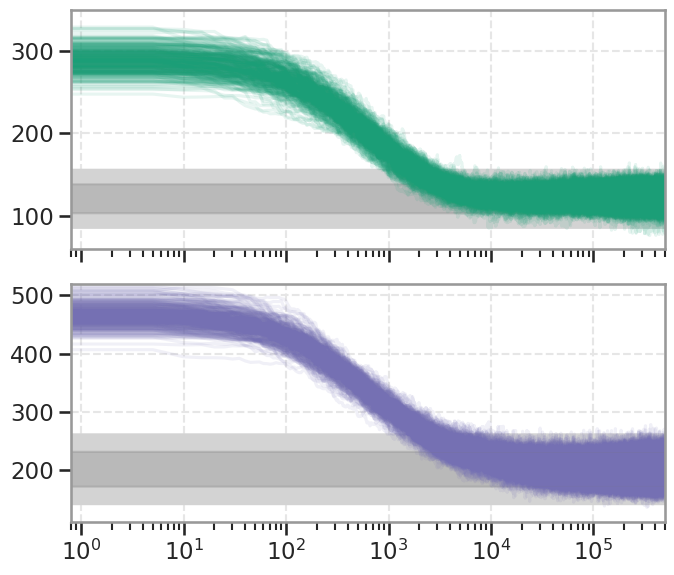

In [10]:
# Plot energy trajectories
xv = np.arange(numiterations, step=int(numiterations * 0.00001))

fig, axs = plt.subplots(2,1,figsize=(7,6), sharex = True)

for traj in energies_1:
    axs[0].plot(xv, traj, color=colorTable['g'], rasterized=True, alpha = 0.1)

# Plot natural energy mean and std -- show +/- 1 std as a gray region
# Plot natural energy mean and std -- show +/- 2 std as a lighter gray region
axs[0].fill_between(xv, nat_mean1 - 2*nat_std1, nat_mean1 + 2*nat_std1, color='lightgray', alpha=1, label=f"{pf1} Nat Mean ± 2 Std", rasterized=True)
axs[0].fill_between(xv, nat_mean1 - nat_std1, nat_mean1 + nat_std1, color='gray', alpha=0.3, label=f"{pf1} Nat Mean ± 1 Std", rasterized=True)
axs[0].set_ylim(60, 350)

for traj in energies_2:
    axs[1].plot(xv, traj, color=colorTable['p'], rasterized=True, alpha = 0.1)

# Plot natural energy mean and std -- show +/- 1 std as a gray region
axs[1].fill_between(xv, nat_mean2 - 2*nat_std2, nat_mean2 + 2*nat_std2, color='lightgray', alpha=1, label=f"{pf2} Nat Mean ± 2 Std", rasterized=True)
axs[1].fill_between(xv, nat_mean2 - nat_std2, nat_mean2 + nat_std2, color='gray', alpha=0.3, label=f"{pf2} Nat Mean ± 1 Std", rasterized=True)
axs[1].set_ylim(110, 520)
axs[1].set_xscale("log")
axs[1].set_xlim(0.8,5e5)

plt.tight_layout()

print(f"{t1} {t2}")

# plt.savefig("202603 Panels/PF00041_PF00072_Overlap218_Temps07_088_EnergyTrajectories_300reps.svg", dpi=500)
print(f"{pf1}")